<a href="https://colab.research.google.com/github/nivetha486/24ADI204_DSV_Team12/blob/main/univariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

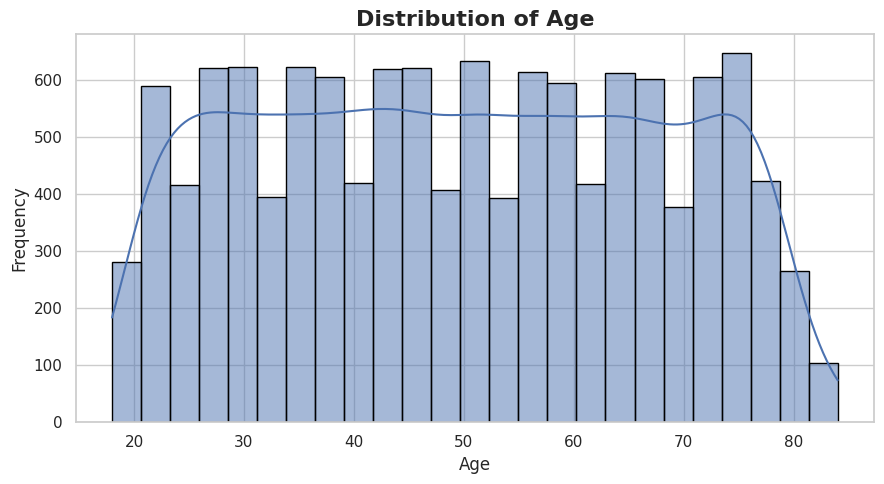

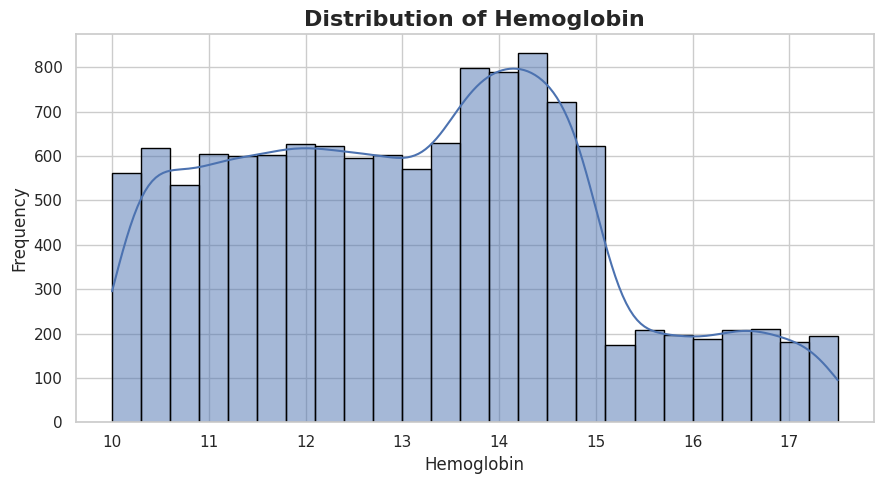

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url="https://raw.githubusercontent.com/nivetha486/24ADI204_DSV_Team12/refs/heads/main/Cleaned_Autoimmune_Disorder_Dataset%20(2).csv"

df=pd.read_csv(url)

sns.set_theme(style="whitegrid")

columns=["Age","Hemoglobin"]

for col in columns:
  plt.figure(figsize=(9,5))
  sns.histplot(data=df,x=col,bins=25,kde=True, edgecolor="black")
  plt.title("Distribution of "+col,fontsize=16,fontweight="bold")
  plt.xlabel(col,fontsize=12)
  plt.ylabel("Frequency",fontsize=12)
  plt.tight_layout()
  plt.show()

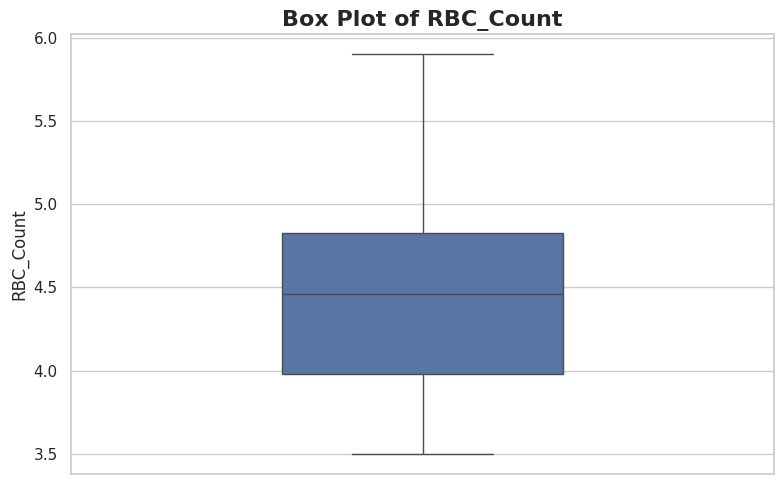

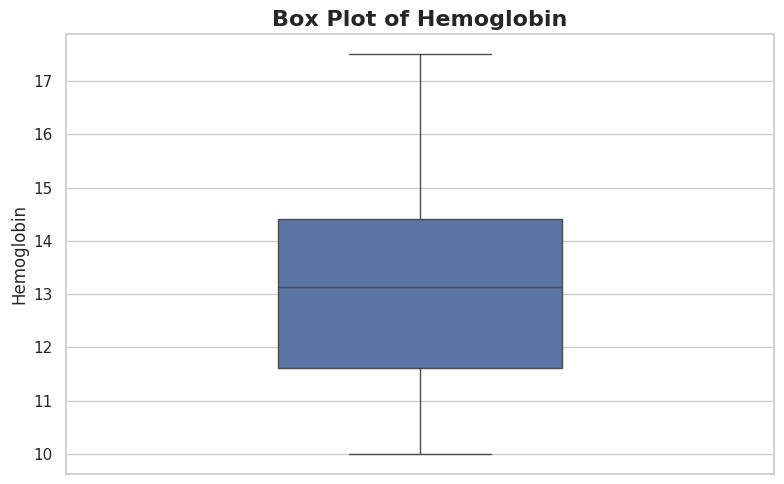

In [ ]:

sns.set_theme(style="whitegrid")

columns=["RBC_Count","Hemoglobin"]

for col in columns:
  plt.figure(figsize=(8,5))
  sns.boxplot(y=df[col],width=0.4 )
  plt.title("Box Plot of "+col,fontsize=16,fontweight="bold")
  plt.ylabel(col,fontsize=12)
  plt.tight_layout()
  plt.show()

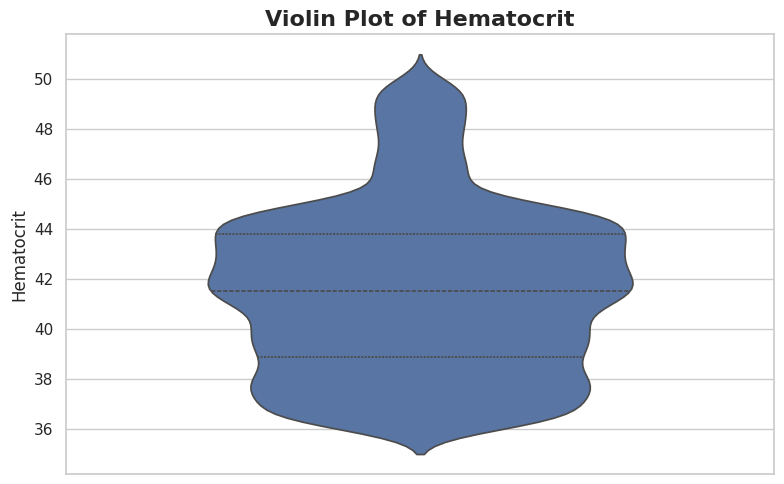

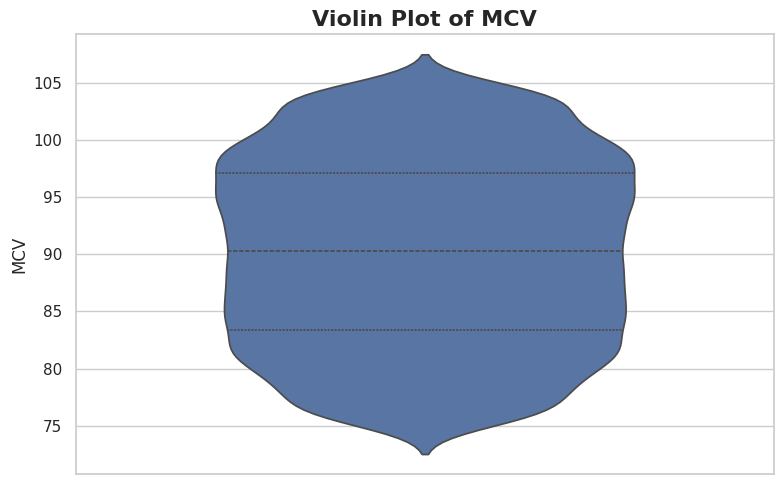

In [ ]:


sns.set_theme(style="whitegrid")

columns=["Hematocrit","MCV"]

for col in columns:
  plt.figure(figsize=(8,5))
  sns.violinplot(y=df[col],inner="quartile",width=0.6)
  plt.title("Violin Plot of "+col,fontsize=16,fontweight="bold")
  plt.ylabel(col,fontsize=12)
  plt.tight_layout()
  plt.show()

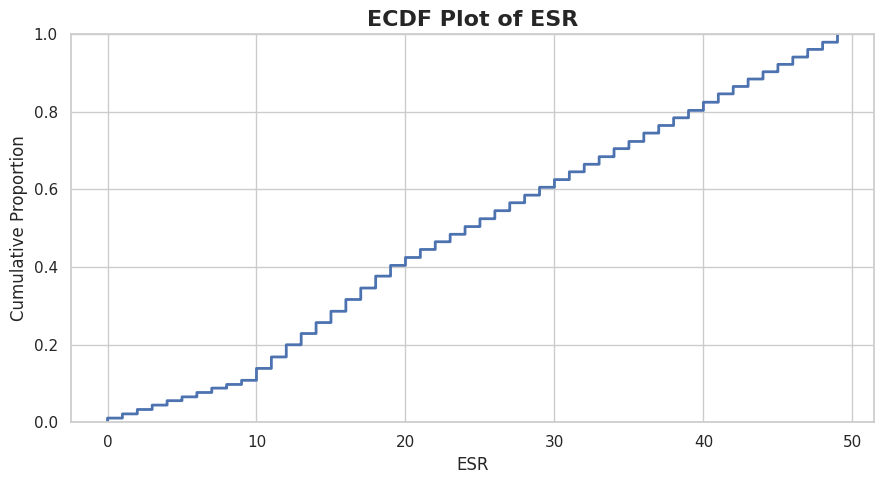

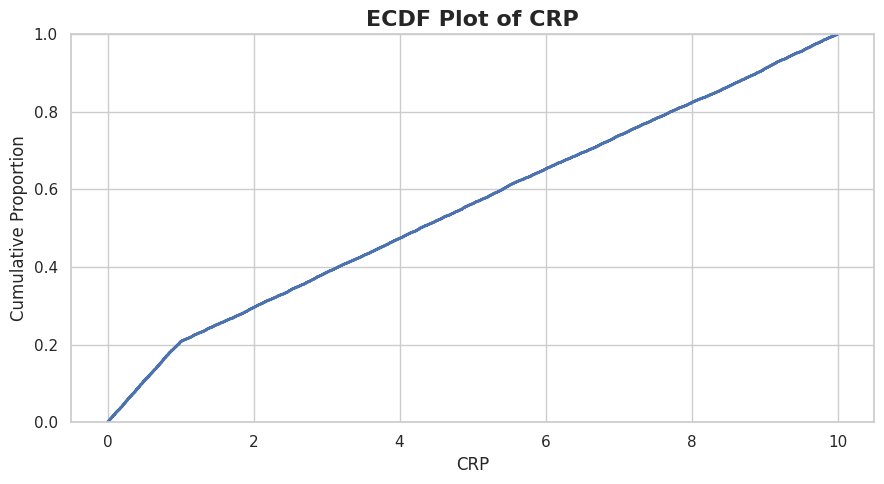

In [ ]:
sns.set_theme(style="whitegrid")

columns=["ESR","CRP"]

for col in columns:
  plt.figure(figsize=(9,5))
  sns.ecdfplot(data=df,x=col,linewidth=2)
  plt.title("ECDF Plot of "+col,fontsize=16,fontweight="bold")
  plt.xlabel(col,fontsize=12)
  plt.ylabel("Cumulative Proportion",fontsize=12)
  plt.tight_layout()
  plt.show()

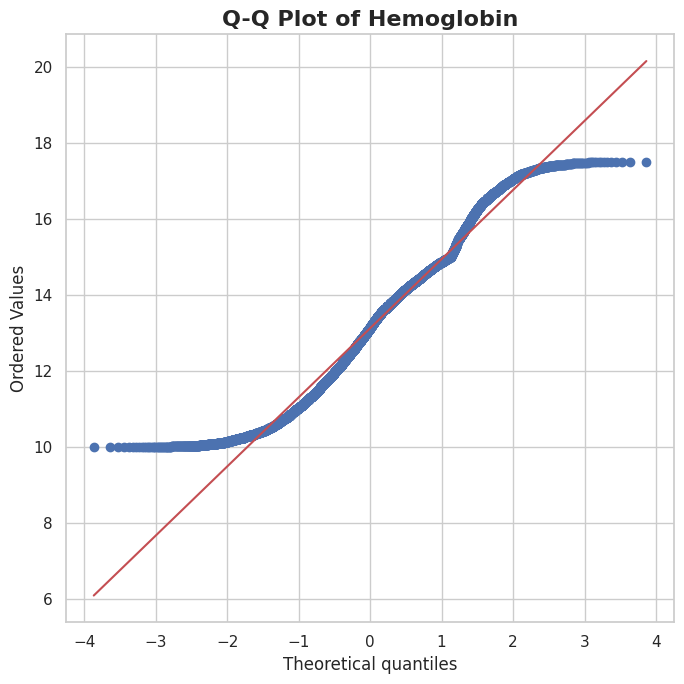

In [ ]:
from scipy import stats
columns=["Age","Hemoglobin"]
for col in columns:
    data=df[col].dropna()

plt.figure(figsize=(7,7))
stats.probplot(data,dist="norm", plot=plt )
plt.title("Q-Q Plot of "+col,fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

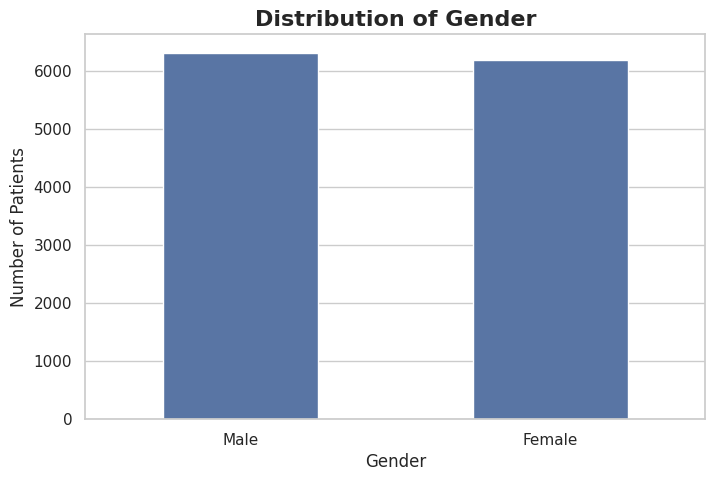

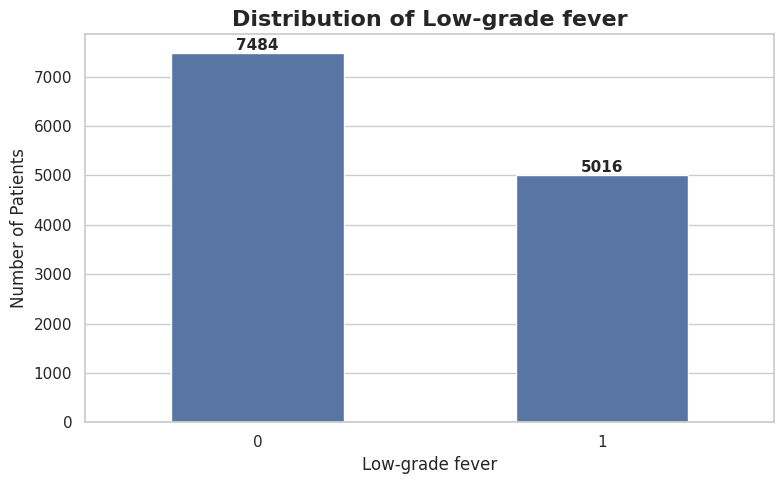

In [38]:
sns.set_theme(style="whitegrid")

columns=["Gender","Low-grade fever"]
for col in columns:
  counts=df[col].value_counts()
  plt.figure(figsize=(8,5))
  bars=sns.barplot(x=counts.index.astype(str),y=counts.values,width=0.5)
  plt.title("Distribution of "+col,fontsize=16,fontweight="bold")
  plt.xlabel(col,fontsize=12)
  plt.ylabel("Number of Patients",fontsize=12)
  plt.xticks(rotation=0)
for bar,value in zip(bars.patches,counts.values):
  plt.text(bar.get_x()+bar.get_width()/2,value+50,str(value),ha="center",fontsize=11,fontweight="bold")
plt.tight_layout()
plt.show()



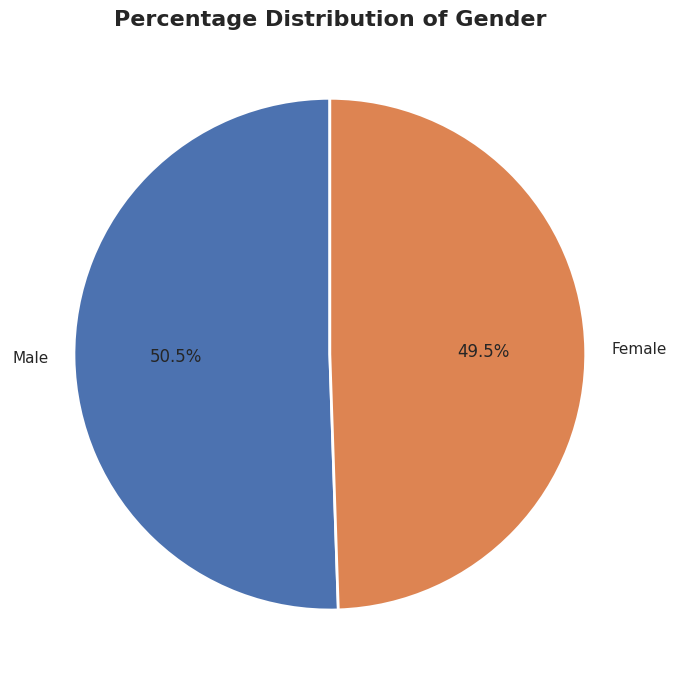

<Figure size 700x700 with 0 Axes>

In [37]:

columns=["Gender","Low-grade fever"]
for col in columns:
  counts=df[col].value_counts()
  plt.figure(figsize=(7,7))
  if col=="Low-grade fever":
    labels=["No","Yes"][:len(counts)]
  else:
    labels=counts.index
    plt.pie(counts.values,labels=labels,autopct="%1.1f%%",startangle=90,wedgeprops={"edgecolor":"white","linewidth":2})
    plt.title("Percentage Distribution of "+col,fontsize=16,fontweight="bold")
    plt.tight_layout()
    plt.show()

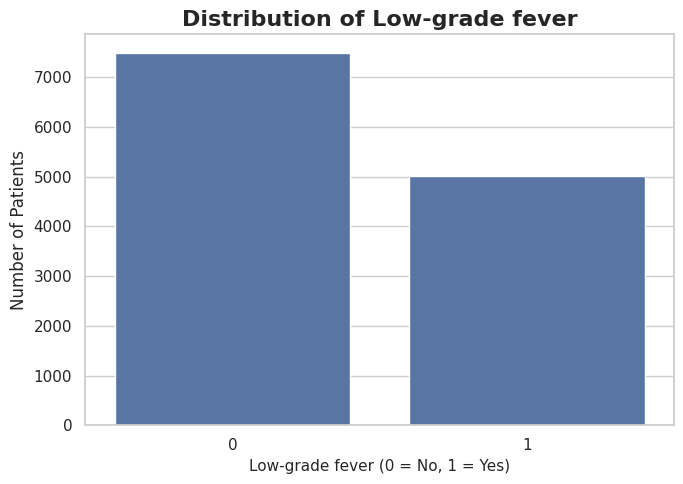

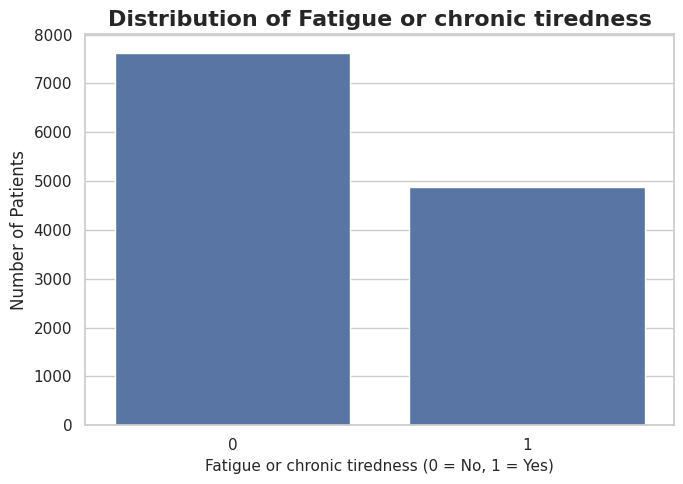

In [ ]:
sns.set_theme(style="whitegrid")

columns=["Low-grade fever","Fatigue or chronic tiredness"]

for col in columns:
  counts=df[col].value_counts().sort_index()

  plt.figure(figsize=(7,5))

  sns.barplot(
                              x=counts.index.astype(str),
                                      y=counts.values
                                          )

  plt.title("Distribution of "+col,fontsize=16,fontweight="bold")
  plt.xlabel(col+" (0 = No, 1 = Yes)",fontsize=11)
  plt.ylabel("Number of Patients",fontsize=12)

  plt.tight_layout()
  plt.show()

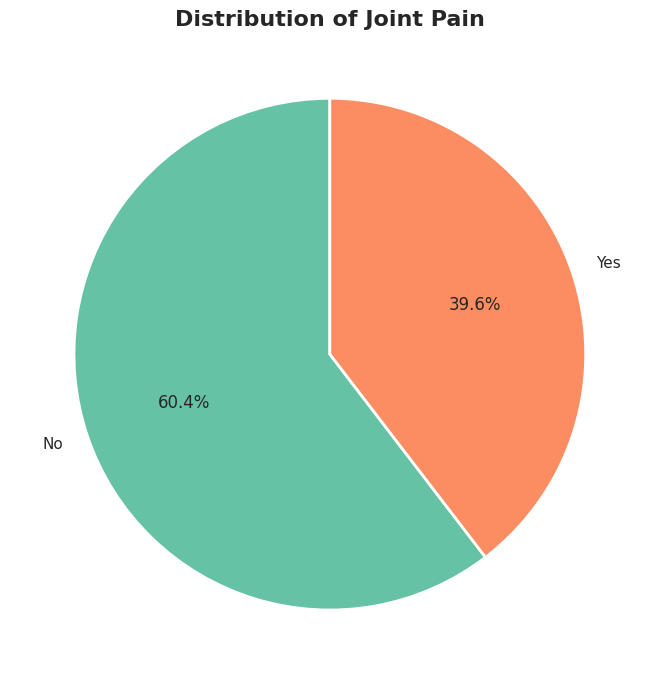

In [ ]:

col="Joint pain"

counts=df[col].value_counts().sort_index()

plt.figure(figsize=(7,7))

plt.pie(
    counts.values,
        labels=["No","Yes"][:len(counts)],
            autopct="%1.1f%%",
                startangle=90,
                    colors=["#66C2A5","#FC8D62"],
                        wedgeprops={"edgecolor":"white","linewidth":2}
                        )

plt.title("Distribution of Joint Pain",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

Skewness values:
Skewness values:
Age : 0.016
CRP : 0.162


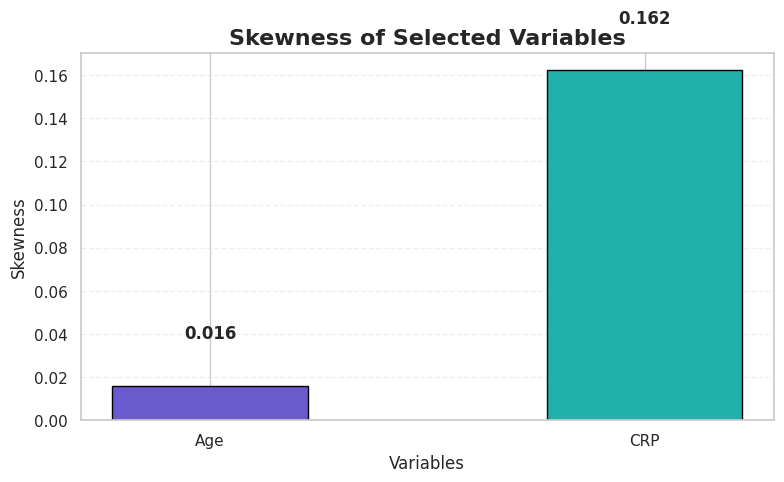

In [ ]:

columns=["Age","CRP"]
skewness=[]
for col in columns:
  data=pd.to_numeric(df[col],errors="coerce").dropna()
  skewness.append(data.skew())
  print("Skewness values:")
for col,value in zip(columns,skewness):
  print(col,":",round(value,3))
plt.figure(figsize=(8,5))
bars=plt.bar(columns,skewness,width=0.45,color=["#6A5ACD","#20B2AA"],edgecolor="black")
plt.axhline(0,linestyle="--",linewidth=1)
plt.title("Skewness of Selected Variables",fontsize=16,fontweight="bold")
plt.xlabel("Variables",fontsize=12)
plt.ylabel("Skewness",fontsize=12)
for bar,value in zip(bars,skewness):
  y=value+0.02 if value>=0 else value-0.02
  va="bottom" if value>=0 else "top"
  plt.text(bar.get_x()+bar.get_width()/2,y,f"{value:.3f}",ha="center",va=va,fontsize=12,fontweight="bold")

plt.grid(axis="y",linestyle="--",alpha=0.3)
plt.tight_layout()
plt.show()